## Comparative study of the 3 available methods for phenological extraction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## RN

In [19]:
# loader les 3 datasets

df_s2_RN = pd.read_csv("../output/NDVI_S2_RN_2016_2026.csv", parse_dates=["date"])
df_s2m_RN = pd.read_csv("../output/NDVI_modis_RN_2016_2026.csv", parse_dates=["date"])
df_hls_RN = pd.read_csv("../output/NDVI_HLS_RN_2016_2026.csv", parse_dates=["date"])

df_s2_RN = df_s2_RN.rename(columns={"mean_ndvi_s2": "mean_ndvi"})

datasets_RN = {
    "Sentinel-2 RN": df_s2_RN,
    "HLS RN": df_hls_RN,
    "S2 + MODIS RN": df_s2m_RN,
}

In [20]:
# disponibilité temporelle

for df in datasets_RN.values():

    df.sort_values("date", inplace=True)

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["doy"] = df["date"].dt.dayofyear

    df["delta_days"] = df["date"].diff().dt.days

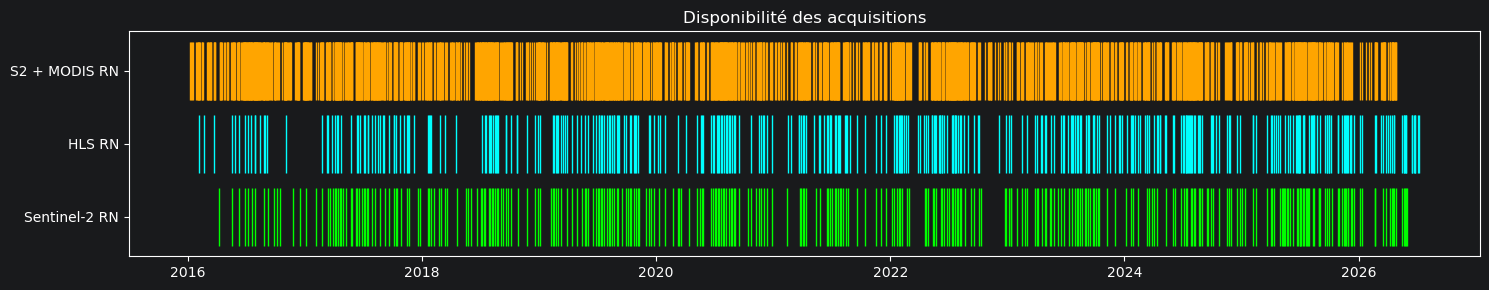

In [21]:
colors = {
    "Sentinel-2 RN": "lime",
    "HLS RN": "cyan",
    "S2 + MODIS RN": "orange"
}

plt.figure(figsize=(15,3))

y = 0

for name, df in datasets_RN.items():

    plt.vlines(df["date"], y, y+0.8,
               color=colors[name],
               linewidth=1)

    y += 1

plt.yticks([0.4,1.4,2.4], datasets_RN.keys())

plt.title("Disponibilité des acquisitions")
plt.tight_layout()
plt.show()

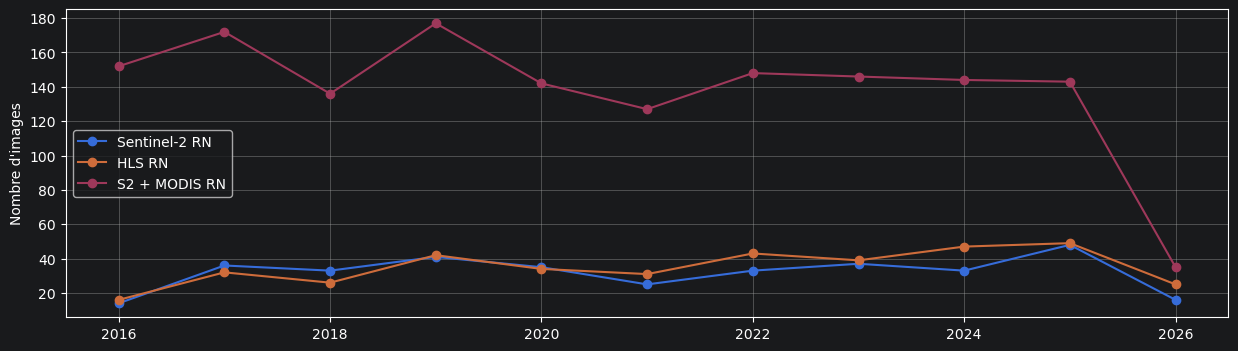

In [6]:
fig, ax = plt.subplots(figsize=(15,4))

for name, df in datasets_RN.items():

    yearly = df.groupby("year").size()

    ax.plot(yearly.index,
            yearly.values,
            marker="o",
            label=name)

ax.legend()
ax.set_ylabel("Nombre d'images")
ax.grid(True)

plt.show()

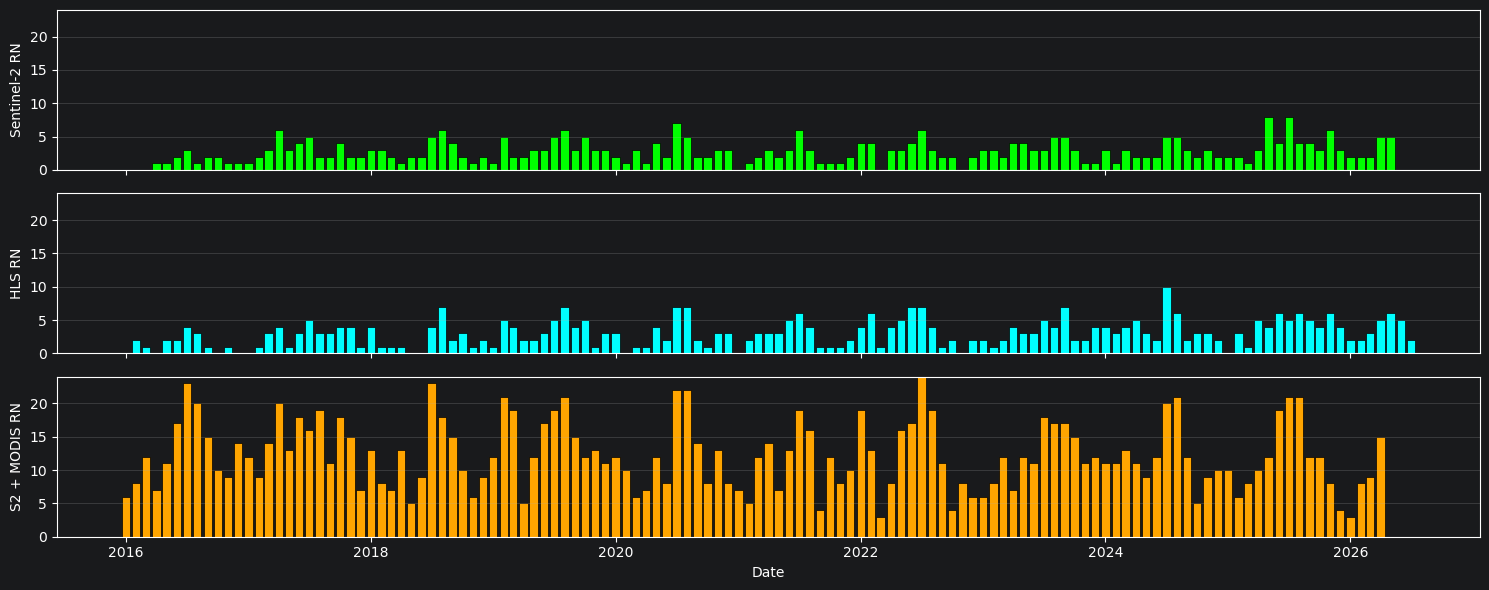

In [9]:
fig, axes = plt.subplots(
    len(datasets_RN), 1,
    figsize=(15, 6),
    sharex=True
)

# Calcul du maximum commun
ymax = max(
    df.set_index("date").resample("MS").size().max()
    for df in datasets_RN.values()
)

for ax, (name, df) in zip(axes, datasets_RN.items()):

    counts = (
        df.set_index("date")
          .resample("MS")
          .size()
    )

    ax.bar(
        counts.index,
        counts.values,
        width=25,                 # largeur des barres (en jours)
        color=colors[name],
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_ylim(0, ymax)
    ax.set_ylabel(name)
    ax.grid(axis="y", alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

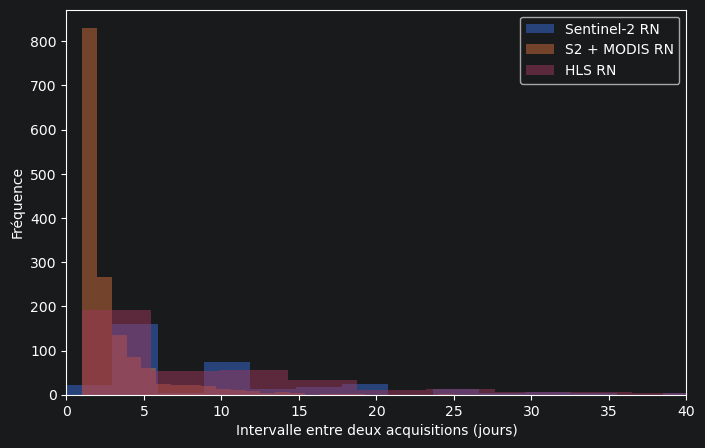

In [16]:
plt.figure(figsize=(8,5))

for name, df in datasets_RN.items():

    plt.hist(df["delta_days"].dropna(),
             bins=25,
             alpha=0.5,
             label=name)

plt.xlim(0, 40)
plt.legend()

plt.xlabel("Intervalle entre deux acquisitions (jours)")
plt.ylabel("Fréquence")

plt.show()

In [ ]:
# valeurs

# plots des phenos, quantifier des ecarts temporels

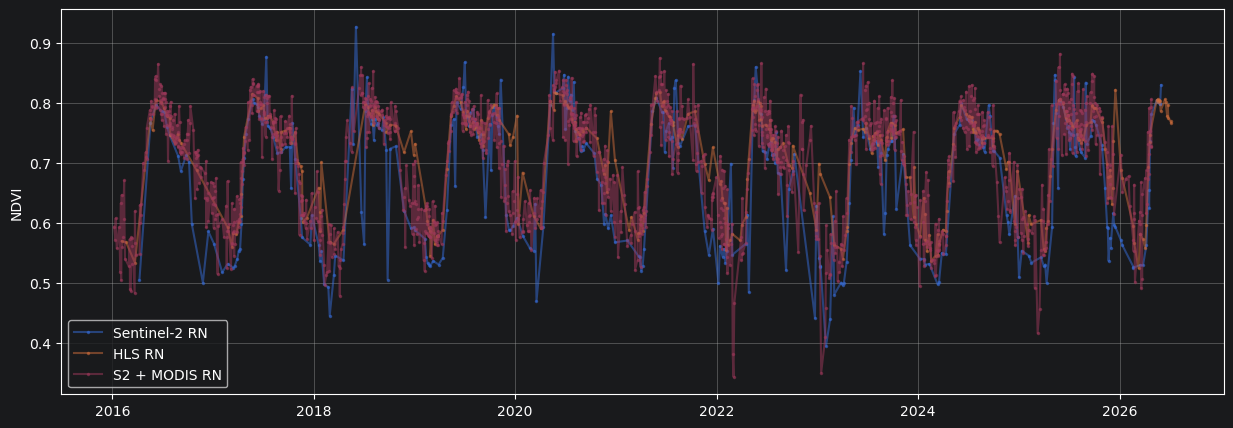

In [23]:
plt.figure(figsize=(15,5))

for name, df in datasets_RN.items():

    plt.plot(df["date"],
             df["mean_ndvi"],
             ".-",
             ms=3,
             alpha=0.5,
             label=name)

plt.legend()
plt.ylabel("NDVI")
plt.grid(True)

plt.show()

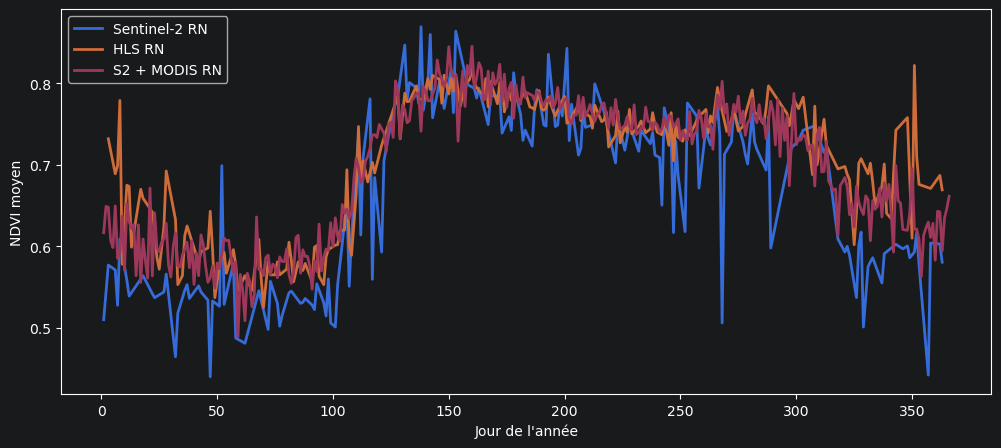

In [24]:
# profil moyen annuel

plt.figure(figsize=(12,5))

for name, df in datasets_RN.items():

    profile = df.groupby("doy")["mean_ndvi"].mean()

    plt.plot(profile.index,
             profile.values,
             linewidth=2,
             label=name)

plt.legend()

plt.xlabel("Jour de l'année")
plt.ylabel("NDVI moyen")

plt.show()

In [ ]:
# variabilité

# precision ? ecart type temporel ? metrique ?

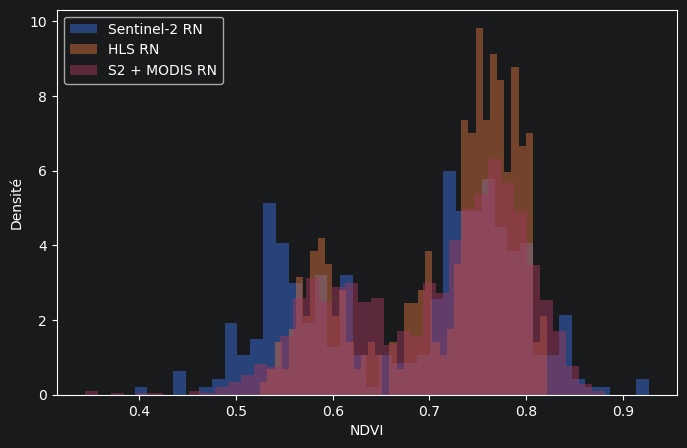

In [26]:
plt.figure(figsize=(8,5))

for name, df in datasets_RN.items():

    plt.hist(
        df["mean_ndvi"],
        bins=40,
        density=True,
        alpha=0.5,
        label=name
    )

plt.xlabel("NDVI")
plt.ylabel("Densité")
plt.legend()
plt.show()

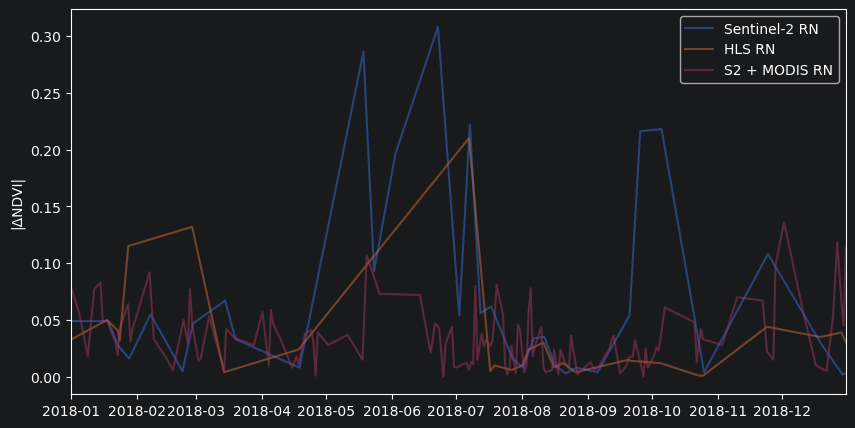

In [31]:
# variations successives NDVI

plt.figure(figsize=(10,5))

for name, df in datasets_RN.items():

    variation = df["mean_ndvi"].diff().abs()

    plt.plot(df["date"],
             variation,
             alpha=0.5,
             label=name)

plt.xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2018-12-31"))
plt.legend()

plt.ylabel("|ΔNDVI|")

plt.show()

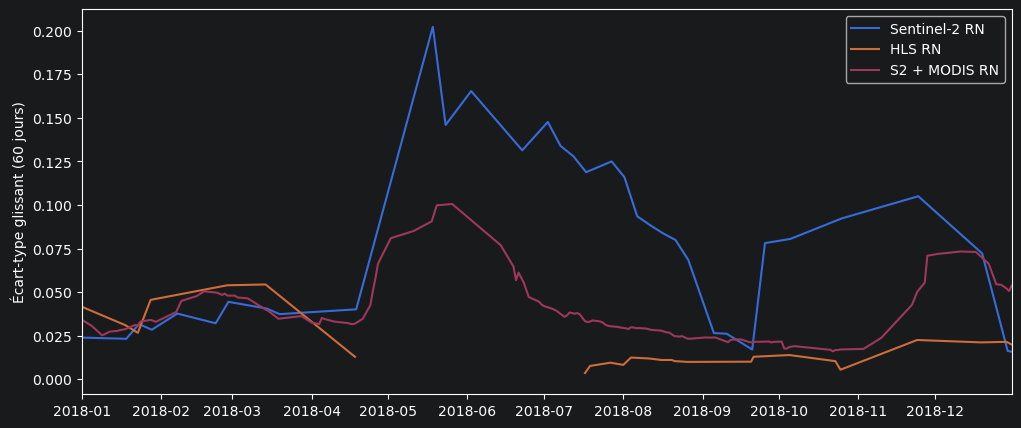

In [23]:
# rolling std

plt.figure(figsize=(12,5))

for name, df in datasets_RN.items():

    rolling = (
        df.set_index("date")["mean_ndvi"]
          .rolling("60D")
          .std()
    )

    plt.plot(
        rolling.index,
        rolling.values,
        label=name
    )


plt.xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2018-12-31"))
plt.legend()
plt.ylabel("Écart-type glissant (60 jours)")
plt.show()

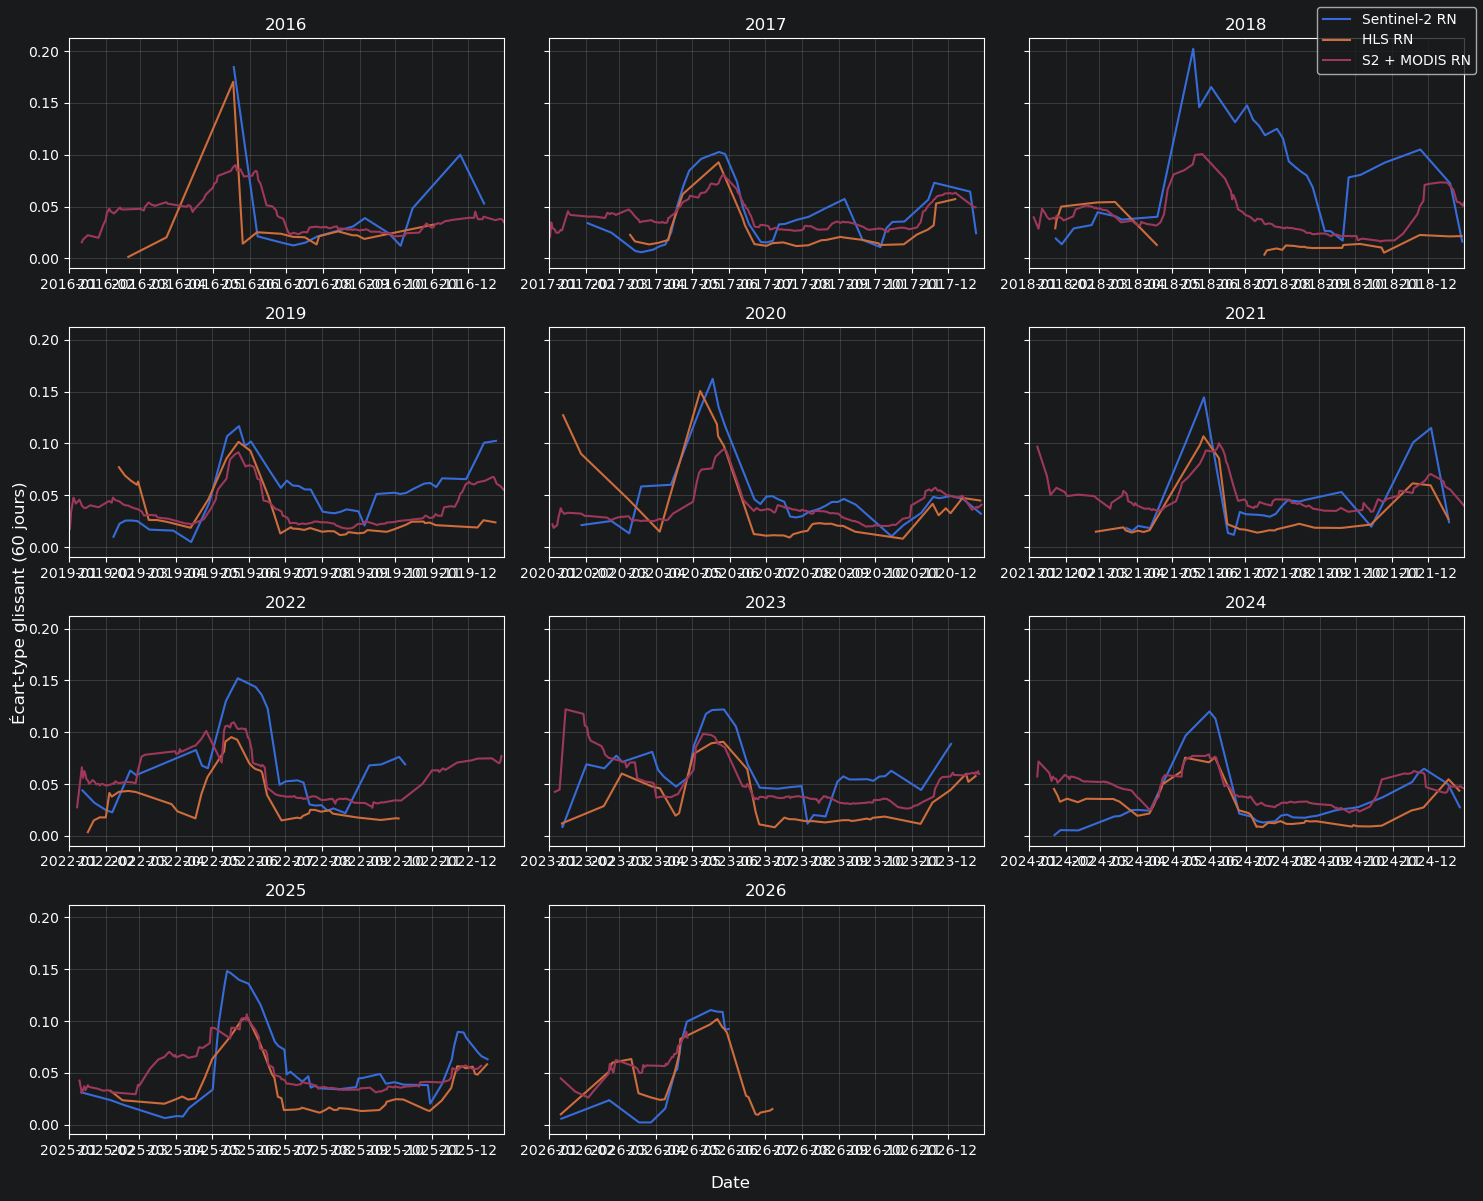

In [57]:
import math

years = sorted(
    set().union(
        *[df["date"].dt.year.unique() for df in datasets_RN.values()]
    )
)

ncols = 3
nrows = math.ceil(len(years) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 3*nrows),
    sharey=True
)

axes = axes.flatten()

for ax, year in zip(axes, years):

    for name, df in datasets_RN.items():

        df_year = df[df["date"].dt.year == year]

        rolling = (
            df_year.set_index("date")["mean_ndvi"]
            .rolling("60D", min_periods=2)
            .std()
        )

        ax.plot(
            rolling.index,
            rolling.values,
            label=name
        )

    ax.set_title(str(year))
    ax.grid(alpha=0.3)

    # limites de l'année
    ax.set_xlim(
        pd.Timestamp(f"{year}-01-01"),
        pd.Timestamp(f"{year}-12-31")
    )


# supprimer les cases vides
for ax in axes[len(years):]:
    ax.remove()

# légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right"
)

fig.supxlabel("Date")
fig.supylabel("Écart-type glissant (60 jours)")

plt.tight_layout()
plt.show()

## RI

In [24]:
# loader les 3 datasets RI

df_s2_RI = pd.read_csv("../output/NDVI_S2_RI_2016_2026.csv", parse_dates=["date"])
df_s2m_RI = pd.read_csv("../output/NDVI_modis_RI_2016_2026.csv", parse_dates=["date"])
df_hls_RI = pd.read_csv("../output/NDVI_HLS_RI_2016_2026.csv", parse_dates=["date"])

df_s2_RI = df_s2_RI.rename(columns={"mean_ndvi_s2": "mean_ndvi"})

datasets_RI = {
    "Sentinel-2 RI": df_s2_RI,
    "HLS RI": df_hls_RI,
    "S2 + MODIS RI": df_s2m_RI,
}

In [25]:
# disponibilité temporelle

for df in datasets_RI.values():

    df.sort_values("date", inplace=True)

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["doy"] = df["date"].dt.dayofyear

    df["delta_days"] = df["date"].diff().dt.days

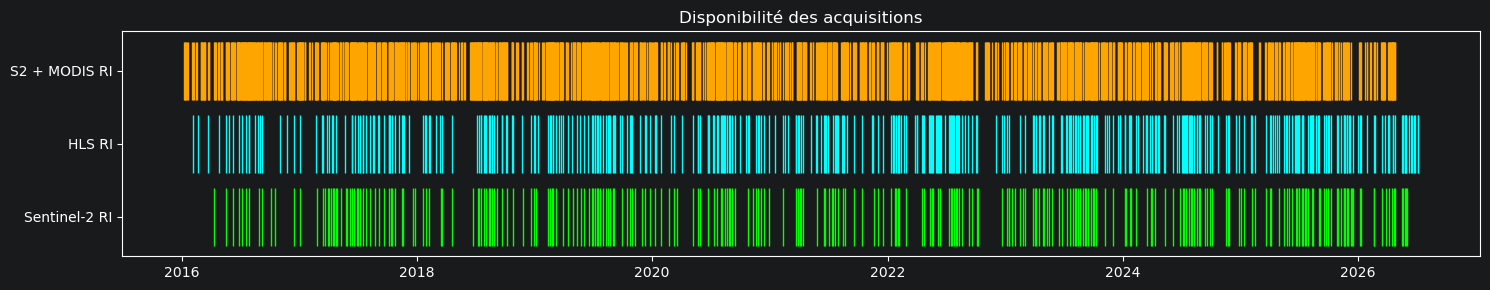

In [26]:
colors = {
    "Sentinel-2 RI": "lime",
    "HLS RI": "cyan",
    "S2 + MODIS RI": "orange"
}

plt.figure(figsize=(15,3))

y = 0

for name, df in datasets_RI.items():

    plt.vlines(df["date"], y, y+0.8,
               color=colors[name],
               linewidth=1)

    y += 1

plt.yticks([0.4,1.4,2.4], datasets_RI.keys())

plt.title("Disponibilité des acquisitions")
plt.tight_layout()
plt.show()

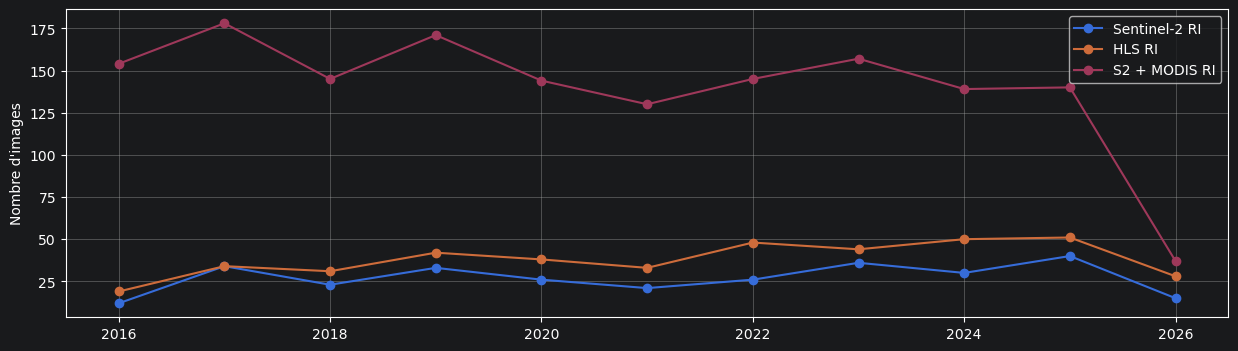

In [27]:
fig, ax = plt.subplots(figsize=(15,4))

for name, df in datasets_RI.items():

    yearly = df.groupby("year").size()

    ax.plot(yearly.index,
            yearly.values,
            marker="o",
            label=name)

ax.legend()
ax.set_ylabel("Nombre d'images")
ax.grid(True)

plt.show()

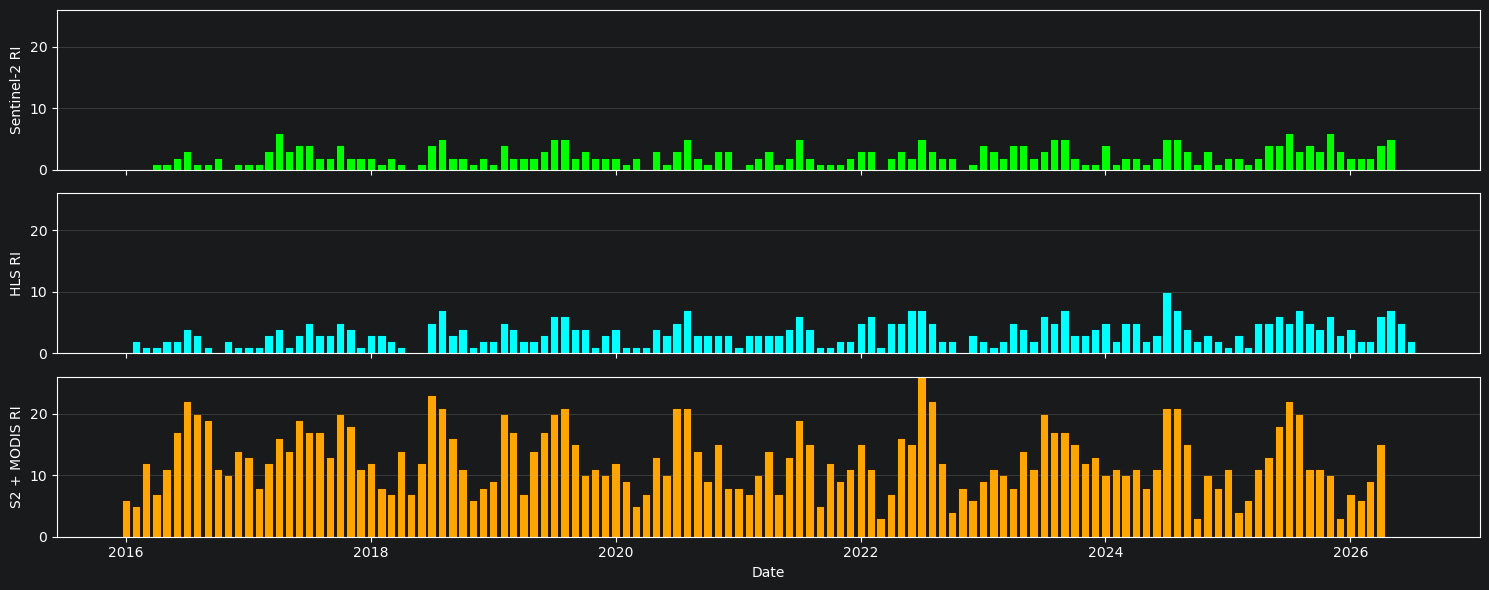

In [10]:
fig, axes = plt.subplots(
    len(datasets_RI), 1,
    figsize=(15, 6),
    sharex=True
)

# Calcul du maximum commun
ymax = max(
    df.set_index("date").resample("MS").size().max()
    for df in datasets_RI.values()
)

for ax, (name, df) in zip(axes, datasets_RI.items()):

    counts = (
        df.set_index("date")
          .resample("MS")
          .size()
    )

    ax.bar(
        counts.index,
        counts.values,
        width=25,                 # largeur des barres (en jours)
        color=colors[name],
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_ylim(0, ymax)
    ax.set_ylabel(name)
    ax.grid(axis="y", alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

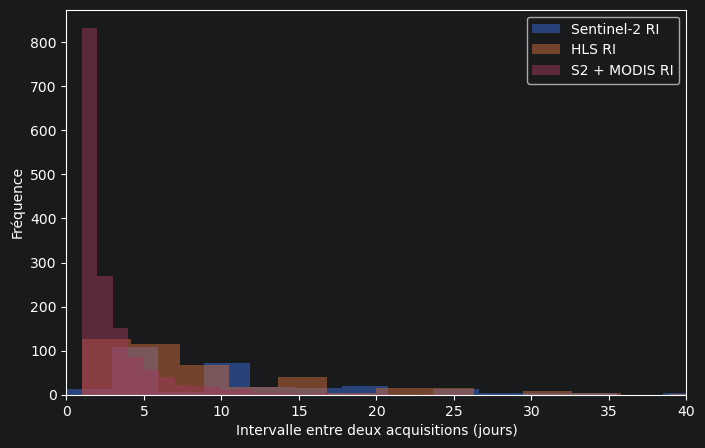

In [11]:
plt.figure(figsize=(8,5))

for name, df in datasets_RI.items():

    plt.hist(df["delta_days"].dropna(),
             bins=25,
             alpha=0.5,
             label=name)

plt.xlim(0, 40)
plt.legend()

plt.xlabel("Intervalle entre deux acquisitions (jours)")
plt.ylabel("Fréquence")

plt.show()

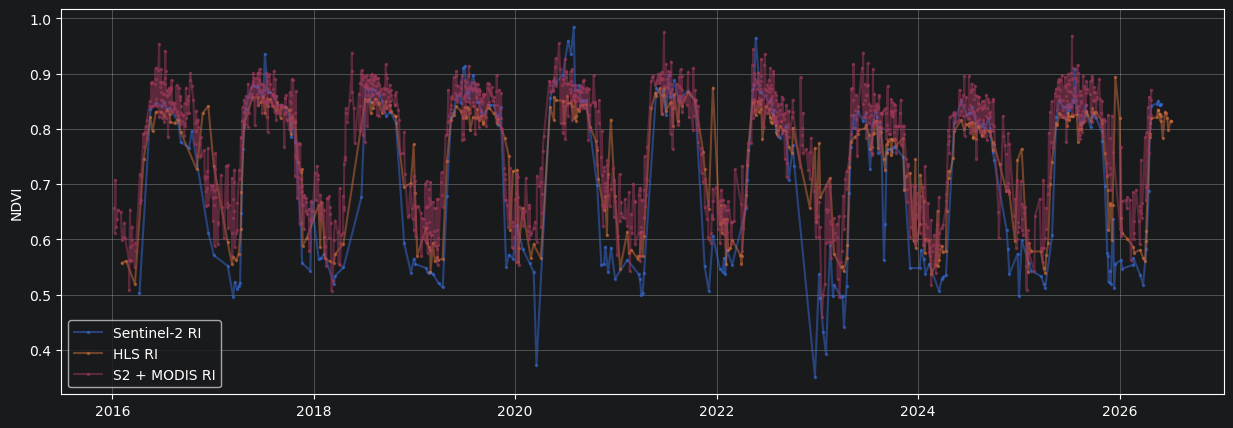

In [12]:
# valeurs

# plots des phenos, quantifier des ecarts temporels
plt.figure(figsize=(15, 5))

for name, df in datasets_RI.items():
    plt.plot(df["date"],
             df["mean_ndvi"],
             ".-",
             ms=3,
             alpha=0.5,
             label=name)

plt.legend()
plt.ylabel("NDVI")
plt.grid(True)

plt.show()

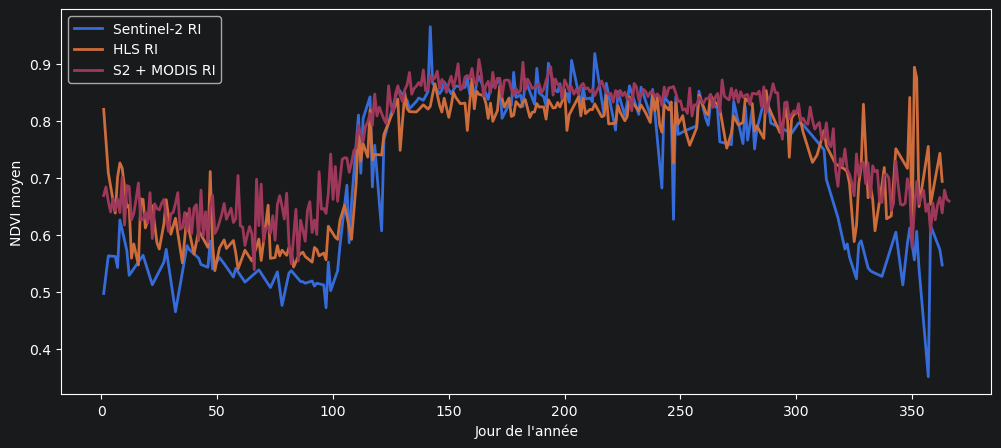

In [13]:
# profil moyen annuel

plt.figure(figsize=(12,5))

for name, df in datasets_RI.items():

    profile = df.groupby("doy")["mean_ndvi"].mean()

    plt.plot(profile.index,
             profile.values,
             linewidth=2,
             label=name)

plt.legend()

plt.xlabel("Jour de l'année")
plt.ylabel("NDVI moyen")

plt.show()

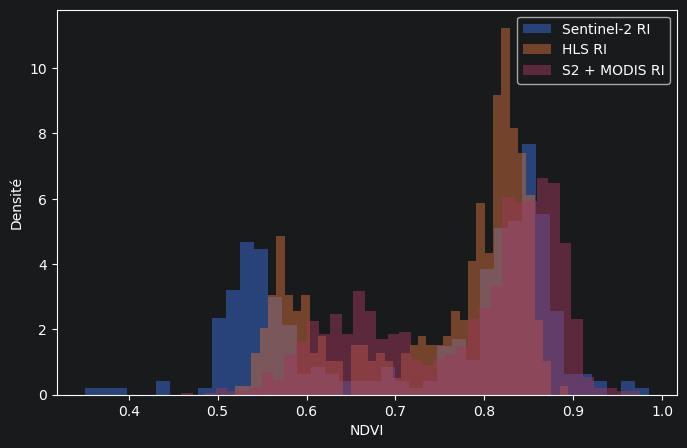

In [14]:
# variabilité

# precision ? ecart type temporel ? metrique ?
plt.figure(figsize=(8, 5))

for name, df in datasets_RI.items():
    plt.hist(
        df["mean_ndvi"],
        bins=40,
        density=True,
        alpha=0.5,
        label=name
    )

plt.xlabel("NDVI")
plt.ylabel("Densité")
plt.legend()
plt.show()

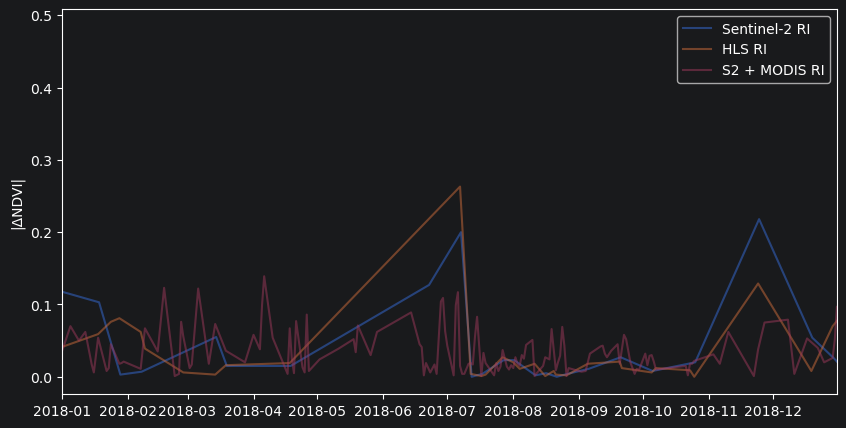

In [15]:
# variations successives NDVI

plt.figure(figsize=(10,5))

for name, df in datasets_RI.items():

    variation = df["mean_ndvi"].diff().abs()

    plt.plot(df["date"],
             variation,
             alpha=0.5,
             label=name)

plt.xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2018-12-31"))
plt.legend()

plt.ylabel("|ΔNDVI|")

plt.show()

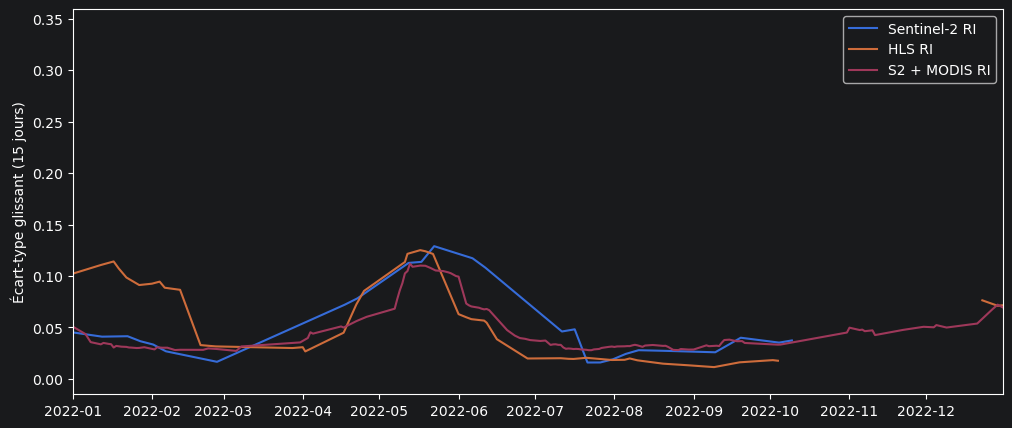

In [16]:
# rolling std

plt.figure(figsize=(12,5))

for name, df in datasets_RI.items():

    rolling = (
        df.set_index("date")["mean_ndvi"]
          .rolling("60D")
          .std()
    )

    plt.plot(
        rolling.index,
        rolling.values,
        label=name
    )


plt.xlim(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"))
plt.legend()
plt.ylabel("Écart-type glissant (15 jours)")
plt.show()

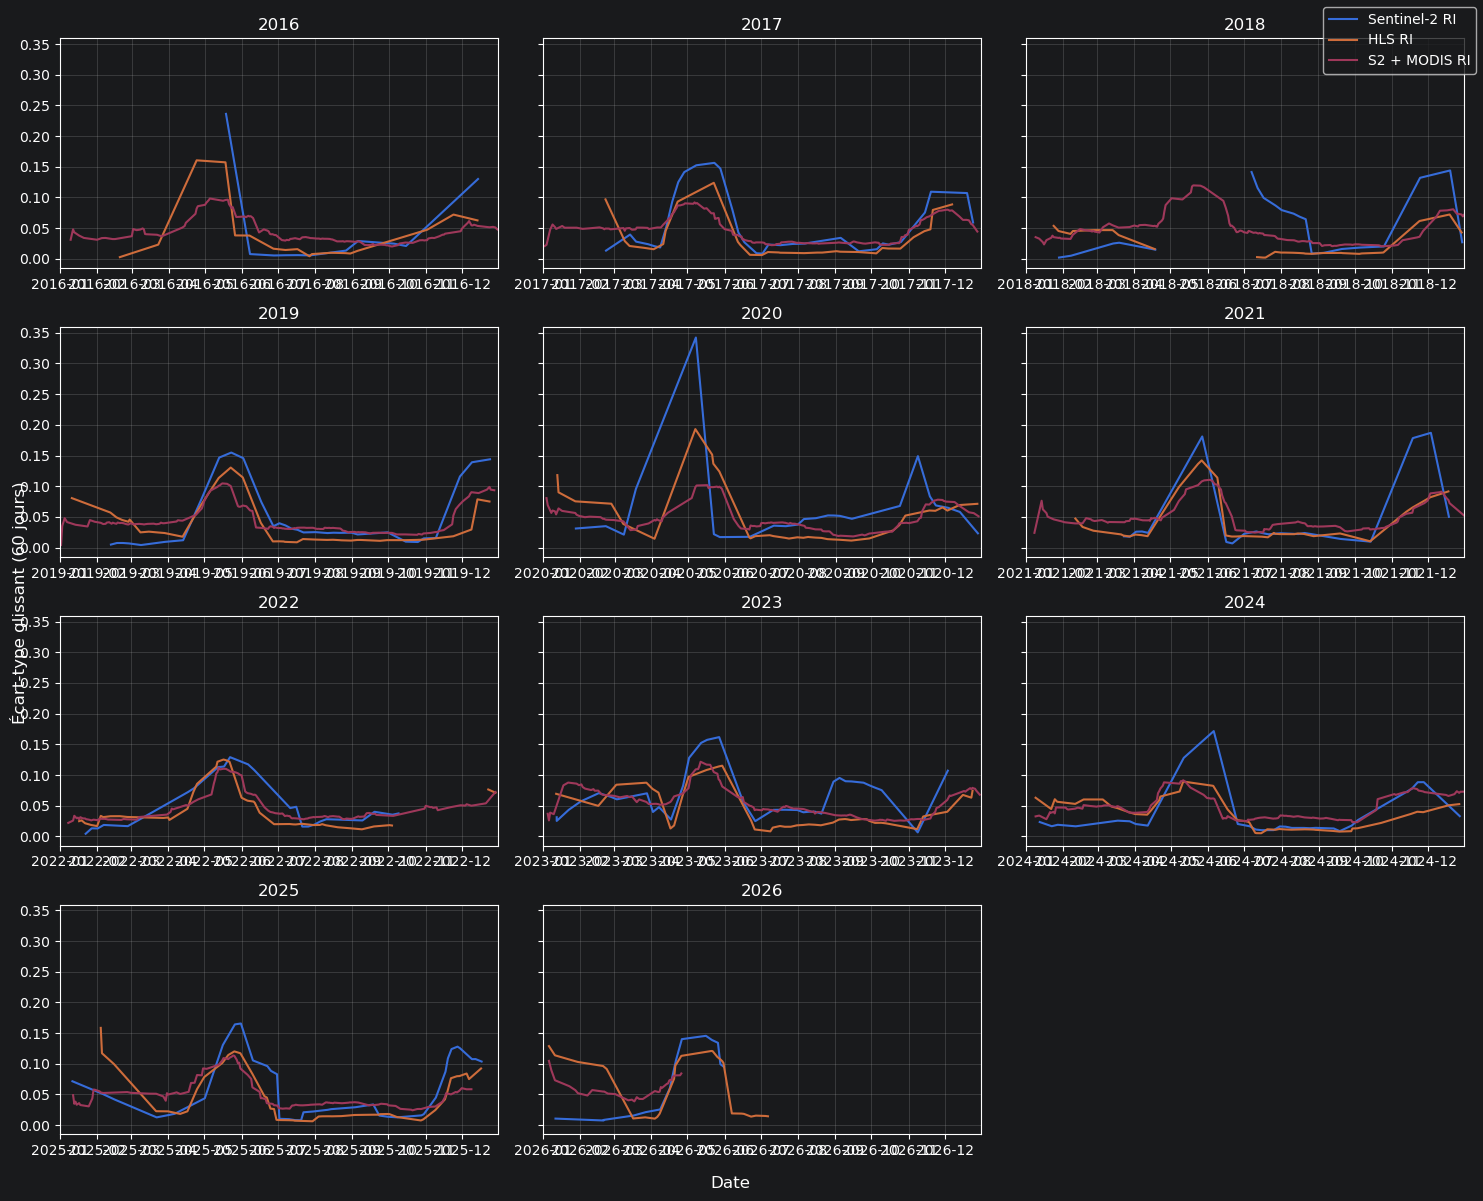

In [17]:
import math

years = sorted(
    set().union(
        *[df["date"].dt.year.unique() for df in datasets_RI.values()]
    )
)

ncols = 3
nrows = math.ceil(len(years) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 3*nrows),
    sharey=True
)

axes = axes.flatten()

for ax, year in zip(axes, years):

    for name, df in datasets_RI.items():

        df_year = df[df["date"].dt.year == year]

        rolling = (
            df_year.set_index("date")["mean_ndvi"]
            .rolling("60D", min_periods=2)
            .std()
        )

        ax.plot(
            rolling.index,
            rolling.values,
            label=name
        )

    ax.set_title(str(year))
    ax.grid(alpha=0.3)

    # limites de l'année
    ax.set_xlim(
        pd.Timestamp(f"{year}-01-01"),
        pd.Timestamp(f"{year}-12-31")
    )


# supprimer les cases vides
for ax in axes[len(years):]:
    ax.remove()

# légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right"
)

fig.supxlabel("Date")
fig.supylabel("Écart-type glissant (60 jours)")

plt.tight_layout()
plt.show()